In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

In [5]:
prices = pd.read_csv(
    "../data/processed/prices.csv",
    index_col=0,
    parse_dates=True
)

prices.head()

,BND,SPY,TSLA
Date,,,
2015-01-02,59.205647,169.687851,14.620667
2015-01-05,59.377579,166.623306,14.006000
2015-01-06,59.549515,165.053909,14.085333
2015-01-07,59.585354,167.110672,14.063333
2015-01-08,59.492188,170.076096,14.041333


In [6]:
tsla = prices["TSLA"].copy()

tsla.head()

Date
2015-01-02    14.620667
2015-01-05    14.006000
2015-01-06    14.085333
2015-01-07    14.063333
2015-01-08    14.041333
Name: TSLA, dtype: float64

Chronological Train/Test Split

In [7]:
train = tsla.loc[:'2024-12-31']

test = tsla.loc['2025-01-01':]

print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 2516
Testing observations: 372


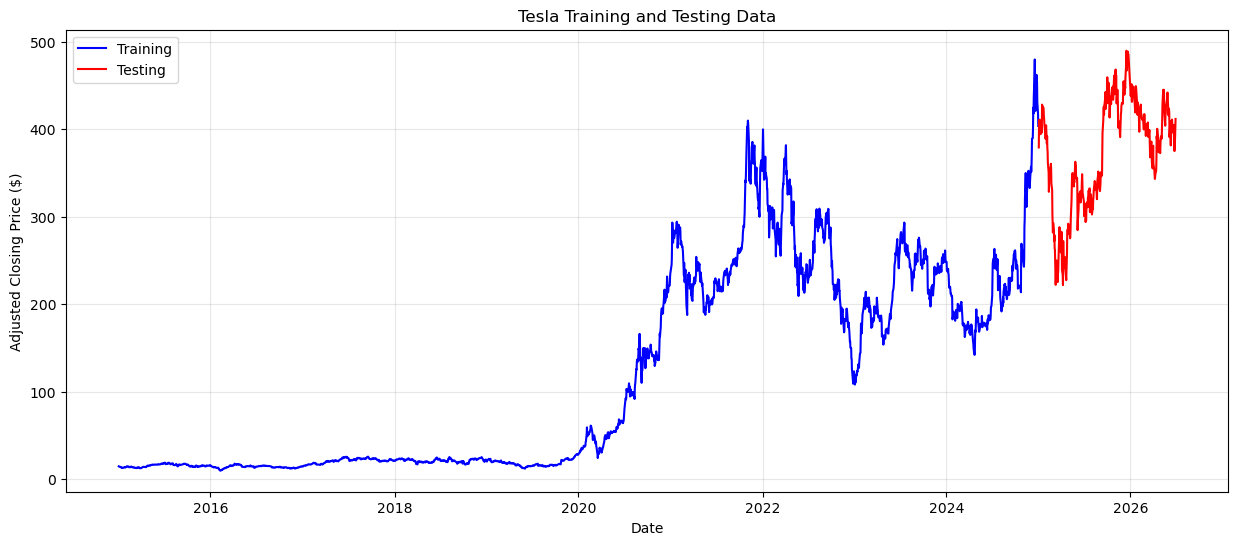

In [8]:
plt.figure(figsize=(15,6))

plt.plot(train,
         label="Training",
         color="blue")

plt.plot(test,
         label="Testing",
         color="red")

plt.title("Tesla Training and Testing Data")

plt.xlabel("Date")

plt.ylabel("Adjusted Closing Price ($)")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

ARIMA

In [9]:
!pip install pmdarima statsmodels

In [10]:
import sys

!{sys.executable} -m pip install pmdarima

from statsmodels.graphics.tsaplots import (
    plot_acf,
    plot_pacf
)

from statsmodels.tsa.arima.model import ARIMA

Visualize ACF and PACF

<Figure size 1400x500 with 0 Axes>

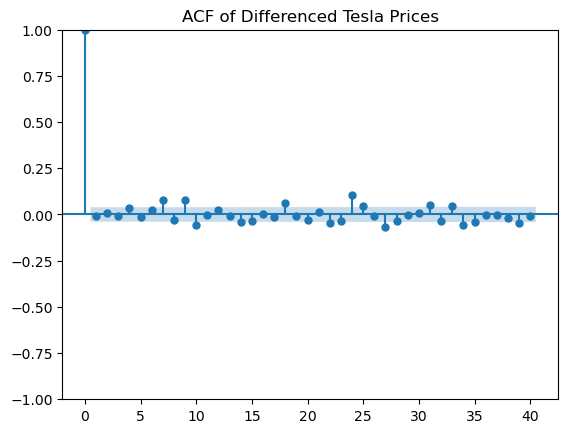

<Figure size 1400x500 with 0 Axes>

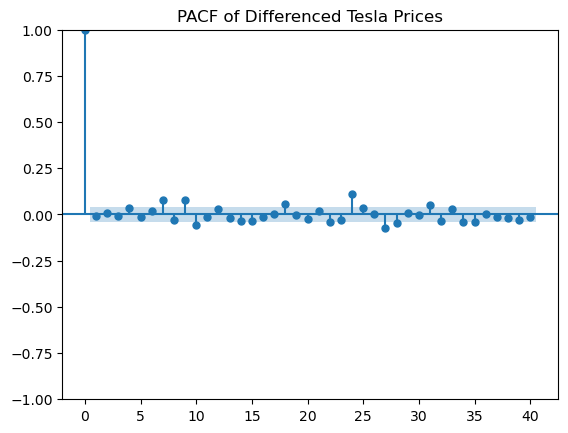

In [11]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(14, 5))
plot_acf(train.diff().dropna(), lags=40)
plt.title("ACF of Differenced Tesla Prices")
plt.show()

plt.figure(figsize=(14, 5))
plot_pacf(train.diff().dropna(), lags=40, method="ywm")
plt.title("PACF of Differenced Tesla Prices")
plt.show()

Automatically Find Best ARIMA Parameters

In [12]:
from pmdarima import auto_arima

auto_model = auto_arima(
    train,
    seasonal=False,
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=16374.056, Time=3.22 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16368.573, Time=0.09 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16370.458, Time=0.21 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16370.460, Time=0.33 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16368.109, Time=0.06 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16372.458, Time=0.59 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 9.544 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2516
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8183.054
Date:                Sun, 05 Jul 2026   AIC                          16368.109
Time:                        22:20:55   BIC                          16373.939
Sample:                             0   HQIC                         16370.225
    

Build the Final ARIMA Model

In [13]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(
    train,
    order=(0,1,0)
)

arima_fit = arima_model.fit()

print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                   TSLA   No. Observations:                 2516
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -8183.054
Date:                Sun, 05 Jul 2026   AIC                          16368.109
Time:                        22:20:55   BIC                          16373.939
Sample:                             0   HQIC                         16370.225
                               - 2516                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        39.2337      0.442     88.858      0.000      38.368      40.099
Ljung-Box (L1) (Q):                   0.12   Jarque-Bera (JB):             11691.05
Prob(Q):                              0.73   Pr

/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Generate Forecasts

In [14]:
forecast_result = arima_fit.get_forecast(
    steps=len(test)
)

forecast = forecast_result.predicted_mean

confidence_intervals = forecast_result.conf_int()

forecast.head()

/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


2516    403.839996
2517    403.839996
2518    403.839996
2519    403.839996
2520    403.839996
Name: predicted_mean, dtype: float64

Plot Predictions

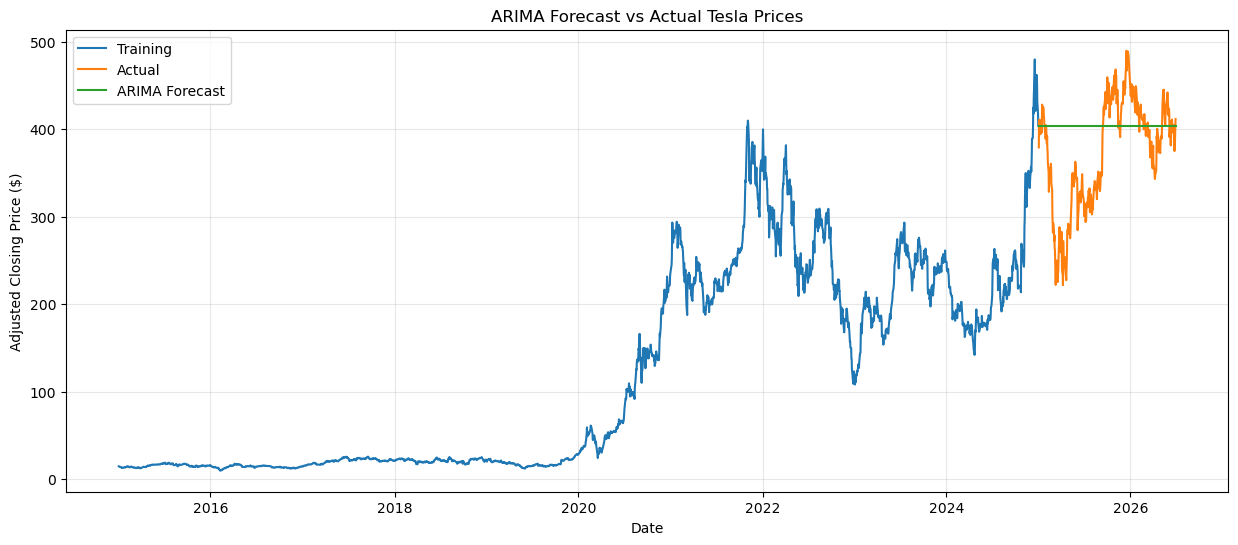

In [15]:
plt.figure(figsize=(15,6))

plt.plot(train,
         label="Training")

plt.plot(test,
         label="Actual")

plt.plot(test.index,
         forecast,
         label="ARIMA Forecast")

plt.title("ARIMA Forecast vs Actual Tesla Prices")

plt.xlabel("Date")

plt.ylabel("Adjusted Closing Price ($)")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

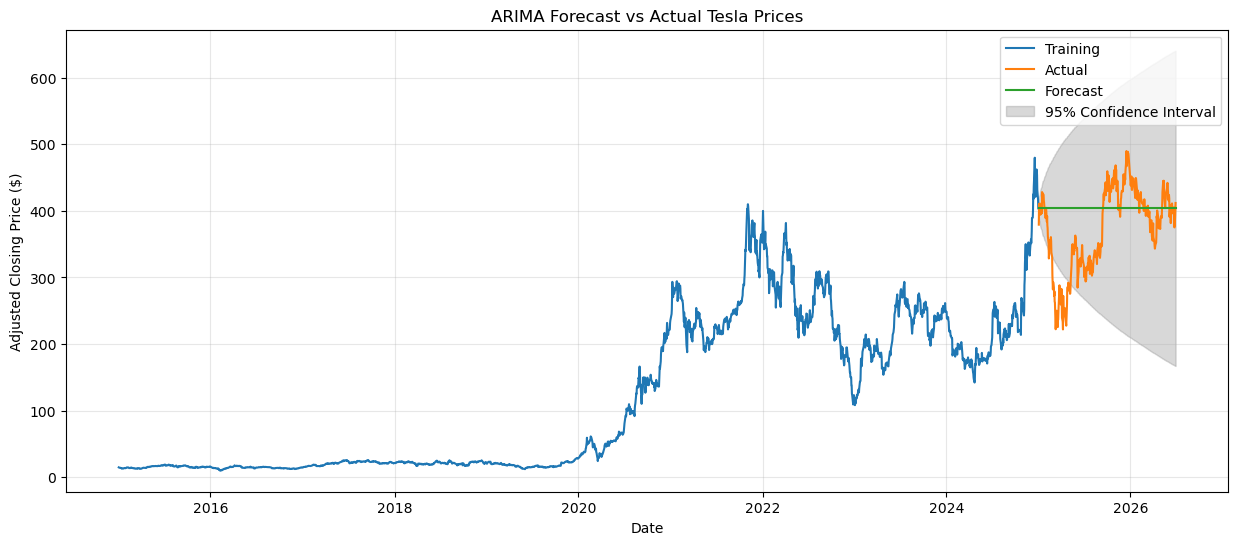

In [16]:
plt.figure(figsize=(15,6))

plt.plot(train, label="Training")
plt.plot(test, label="Actual")
plt.plot(test.index, forecast, label="Forecast")

plt.fill_between(
    test.index,
    confidence_intervals.iloc[:,0],
    confidence_intervals.iloc[:,1],
    color="gray",
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.title("ARIMA Forecast vs Actual Tesla Prices")

plt.xlabel("Date")
plt.ylabel("Adjusted Closing Price ($)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

Evaluate the ARIMA Model

In [17]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import numpy as np

mae = mean_absolute_error(test, forecast)

rmse = np.sqrt(mean_squared_error(test, forecast))

mape = mean_absolute_percentage_error(test, forecast)

print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4%}")

MAE : 54.4412
RMSE: 70.5393
MAPE: 17.2407%


### ARIMA Model Evaluation Summary

The ARIMA model achieved an MAE of 54.44, an RMSE of 70.54, and a MAPE of 17.24%. These results indicate that the model captures the general price level but struggles to follow Tesla's rapid price fluctuations. This behaviour is expected because the selected ARIMA(0,1,0) model represents a random walk, where future prices are assumed to be close to the most recent observed price. These metrics will serve as the baseline for comparison with the LSTM model.

# Long Short-Term Memory (LSTM) Model

Unlike ARIMA, which is a statistical forecasting model, Long Short-Term Memory (LSTM) is a deep learning model designed to learn complex temporal patterns in sequential data. LSTM networks are capable of remembering long-term dependencies and are widely used for financial time series forecasting.

In [15]:
import sys

%pip install tensorflow --no-cache-dir --default-timeout=1000

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

from sklearn.preprocessing import MinMaxScaler

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 MB 718.1 kB/s eta 0:00:0000:0100:08
Note: you may need to restart the kernel to use updated packages.


2026-07-05 22:03:08.772368: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [1]:
import tensorflow as tf

print(tf.__version__)

2026-07-05 22:07:07.594207: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2.16.2


In [18]:
tsla = prices["TSLA"]
train = tsla[:'2024-12-31']
test = tsla['2025-01-01':]

print("Training samples:", len(train))
print("Testing samples:", len(test))

Training samples: 2516
Testing samples: 372


In [19]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))

test_scaled = scaler.transform(test.values.reshape(-1, 1))

In [20]:
X_train = []
y_train = []

window_size = 60

for i in range(window_size, len(train_scaled)):
    
    X_train.append(train_scaled[i-window_size:i, 0])
    
    y_train.append(train_scaled[i, 0])

X_train = np.array(X_train)
y_train = np.array(y_train)

In [21]:
print(X_train.shape)
print(y_train.shape)

(2456, 60)
(2456,)


In [22]:
X_train = np.reshape(
    X_train,
    (X_train.shape[0],
     X_train.shape[1],
     1)
)

print(X_train.shape)

(2456, 60, 1)


In [23]:
print(X_train.shape)
print(y_train.shape)

(2456, 60, 1)
(2456,)


Building the LSTM Network

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()


model.add(
    LSTM(
        units=64,
        return_sequences=True,
        input_shape=(X_train.shape[1], 1)
    )
)

model.add(Dropout(0.2))

model.add(
    LSTM(
        units=64,
        return_sequences=False
    )
)

model.add(Dropout(0.2))


model.add(Dense(25))
model.add(Dense(1))

Compile the Model

In [25]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

View the Model

In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,571 (201.45 KB)

 Trainable params: 51,571 (201.45 KB)

 Non-trainable params: 0 (0.00 B)